#### Required Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("dataset/lung_cancer_dataset.csv")
df

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...
49995,149995,81,Female,9.386431,Medium,No,Yes,No,Moderate,No,Yes
49996,149996,28,Male,99.471718,Medium,No,Yes,No,Moderate,No,Yes
49997,149997,90,Male,14.349722,Low,Yes,Yes,No,Heavy,Yes,Yes
49998,149998,33,Female,87.012555,Medium,No,No,Yes,Moderate,No,No


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        33338 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB


In [175]:
df[["age", "pack_years"]].describe()

,age,pack_years
count,50000.000000,50000.000000
mean,58.857040,49.963424
std,23.958266,28.852082
min,18.000000,0.002753
25%,38.000000,24.774558
50%,59.000000,50.177634
75%,80.000000,75.066740
max,100.000000,99.999204


### Data Visualization

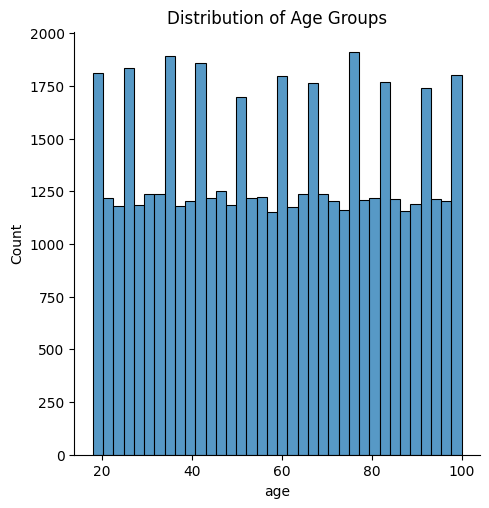

In [176]:
sns.displot(data=df, x="age")
plt.title("Distribution of Age Groups")
plt.show()

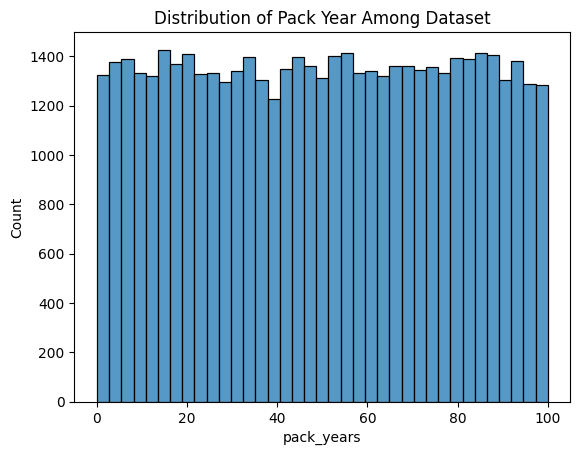

In [177]:
sns.histplot(data=df, x="pack_years")
plt.title("Distribution of Pack Year Among Dataset")
plt.show()

In [178]:
df["lung_cancer"].value_counts()

lung_cancer
Yes    34364
No     15636
Name: count, dtype: int64

There seems to be a very high imbalance of our target variable.

Our dataset is distributed equally among different smoking levels.

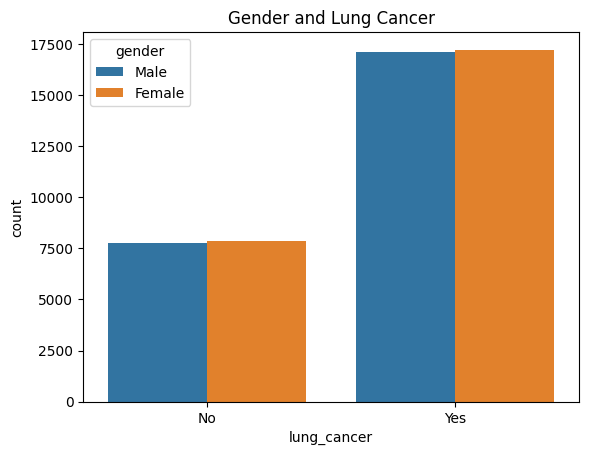

In [179]:
sns.countplot(data=df, x="lung_cancer", hue="gender")
plt.title("Gender and Lung Cancer")
plt.show()

There seems to be noe density difference between male and female patients regarding the target variable.

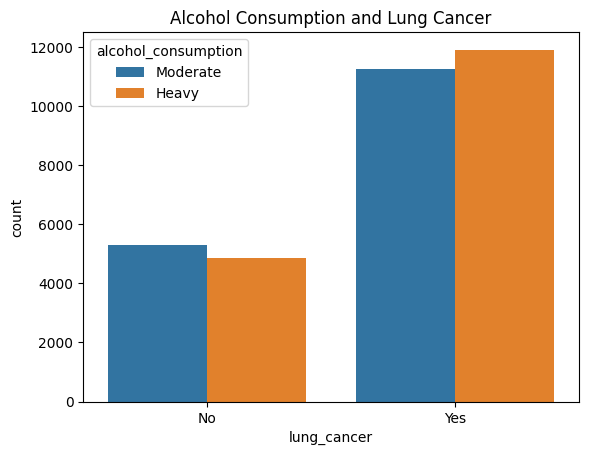

In [180]:
sns.countplot(data=df, x="lung_cancer", hue="alcohol_consumption")
plt.title("Alcohol Consumption and Lung Cancer")
plt.show()

Between modareta and heavy drinking, there is not a significant effect on lung cancer.

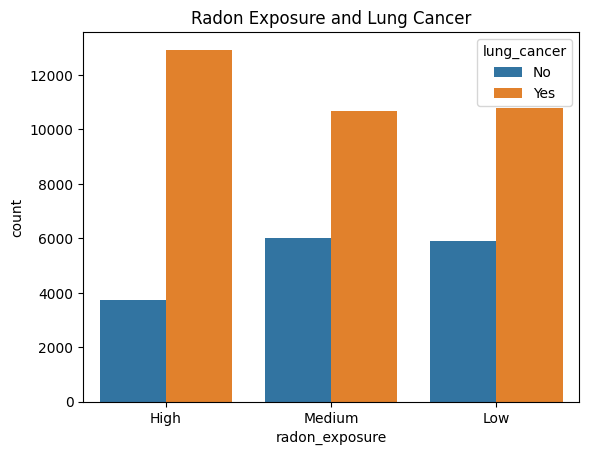

In [181]:
sns.countplot(data=df, x="radon_exposure", hue="lung_cancer")
plt.title("Radon Exposure and Lung Cancer")
plt.show()

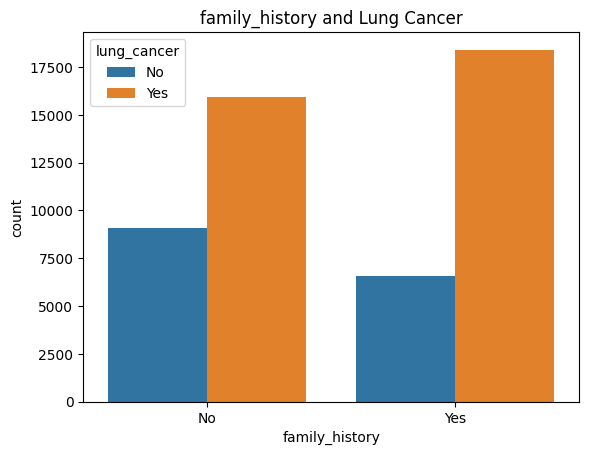

In [182]:
sns.countplot(data=df, x="family_history", hue="lung_cancer")
plt.title("family_history and Lung Cancer")
plt.show()

In [183]:
df["alcohol_consumption"].value_counts()

alcohol_consumption
Heavy       16762
Moderate    16576
Name: count, dtype: int64

In [184]:
indexes_of_missing_all = df[df["alcohol_consumption"].isna()].index

In [185]:
df.loc[indexes_of_missing_all]

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes
8,100008,41,Female,7.824233,High,No,Yes,Yes,NaN,Yes,No
14,100014,55,Male,31.979303,Medium,No,No,No,NaN,Yes,No
15,100015,19,Female,53.669016,Medium,No,Yes,No,NaN,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
49981,149981,74,Male,15.169124,Medium,Yes,Yes,Yes,NaN,Yes,Yes
49986,149986,66,Male,7.070265,Medium,No,Yes,Yes,NaN,No,No
49991,149991,54,Female,26.726782,Low,No,No,No,NaN,No,No
49994,149994,58,Male,91.933528,Low,No,No,Yes,NaN,Yes,Yes


In [4]:
def fill_missin_randomized(df):
    idx = df[df["alcohol_consumption"].isna()].index
    shuffled = np.random.permutation(idx)
    half = len(shuffled) // 2
    moderate_idx = shuffled[:half]
    heavy_idx = shuffled[half:]

    df.loc[moderate_idx, "alcohol_consumption"] = "Moderate"
    df.loc[heavy_idx, "alcohol_consumption"] = "Heavy"
    return df

df = fill_missin_randomized(df)

In [5]:
df["alcohol_consumption"].value_counts()

alcohol_consumption
Heavy       25093
Moderate    24907
Name: count, dtype: int64

In [188]:
df.columns

Index(['patient_id', 'age', 'gender', 'pack_years', 'radon_exposure',
       'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis',
       'alcohol_consumption', 'family_history', 'lung_cancer'],
      dtype='object')

In [6]:
cols_to_change = ["asbestos_exposure", "secondhand_smoke_exposure", "copd_diagnosis", "family_history", "lung_cancer"]
df[cols_to_change] = df[cols_to_change].replace({"No": 0, "Yes": 1})

C:\Users\celik\AppData\Local\Temp\ipykernel_14008\3430191411.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_to_change] = df[cols_to_change].replace({"No": 0, "Yes": 1})


In [7]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

In [8]:
df["alcohol_consumption"] = df["alcohol_consumption"].map({"Moderate": 0, "Heavy": 1})

In [9]:
df = df.drop(columns=["patient_id"])

In [10]:
df

,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,69,1,66.025244,High,0,0,1,0,0,0
1,32,0,12.780800,High,0,1,1,0,1,1
2,89,0,0.408278,Medium,1,1,1,1,0,1
3,78,0,44.065232,Low,0,1,0,0,0,1
4,38,0,44.432440,Medium,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
49995,81,0,9.386431,Medium,0,1,0,0,0,1
49996,28,1,99.471718,Medium,0,1,0,0,0,1
49997,90,1,14.349722,Low,1,1,0,1,1,1
49998,33,0,87.012555,Medium,0,0,1,0,0,0


In [194]:
df.select_dtypes(include=np.number).corr()["lung_cancer"]

age                          0.120938
gender                       0.000122
pack_years                   0.210301
asbestos_exposure            0.157360
secondhand_smoke_exposure    0.096890
copd_diagnosis               0.153550
alcohol_consumption          0.019938
family_history               0.106875
lung_cancer                  1.000000
Name: lung_cancer, dtype: float64

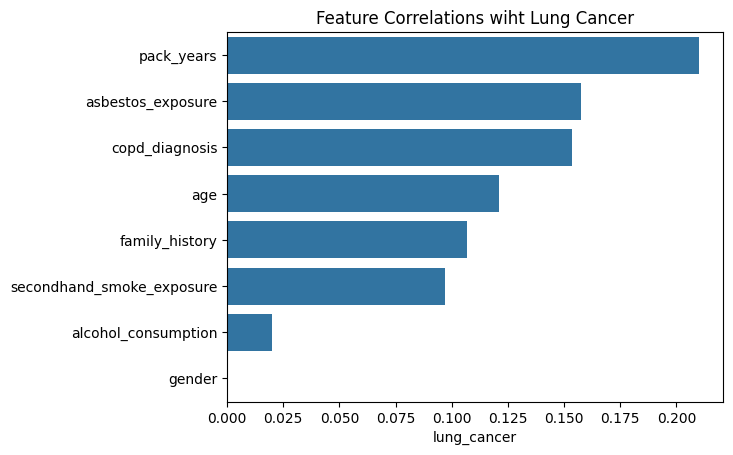

In [ ]:
corr_df = df.select_dtypes(include=np.number).corr()["lung_cancer"]
corr_df = corr_df.reset_index()
corr_df = corr_df.rename(columns={"index": "features"}).drop(index=8).sort_values(by="lung_cancer", ascending=False)

sns.barplot(data=corr_df, x="lung_cancer", y="features")
plt.title("Feature Correlations with Lung Cancer")
plt.ylabel(None)
plt.show()

### Data Preprocessings

In [13]:
radon_expo_mapping = {"High": "high", "Medium": "medium", "Low": "low"}
df["radon_exposure"] = df["radon_exposure"].map(radon_expo_mapping)

In [14]:
df

,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,69,1,66.025244,high,0,0,1,0,0,0
1,32,0,12.780800,high,0,1,1,0,1,1
2,89,0,0.408278,medium,1,1,1,1,0,1
3,78,0,44.065232,low,0,1,0,0,0,1
4,38,0,44.432440,medium,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
49995,81,0,9.386431,medium,0,1,0,0,0,1
49996,28,1,99.471718,medium,0,1,0,0,0,1
49997,90,1,14.349722,low,1,1,0,1,1,1
49998,33,0,87.012555,medium,0,0,1,0,0,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df["lung_cancer"],
                                                    test_size=0.25, random_state=42, stratify=df["lung_cancer"])

In [16]:
column_to_encode = ["radon_exposure"]
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(X_train[column_to_encode])

encoded_cols = encoder.get_feature_names_out(column_to_encode)
X_train[encoded_cols] = encoder.transform(X_train[column_to_encode])
X_test[encoded_cols] = encoder.transform(X_test[column_to_encode])

X_train = X_train.drop(columns=column_to_encode)
X_test = X_test.drop(columns=column_to_encode)

In [17]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train[scaler.get_feature_names_out()] = scaler.transform(X_train)
X_test[scaler.get_feature_names_out()] = scaler.transform(X_test)

In [18]:
# resampling for class imbalance
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### Model Testing

In [19]:
def test_model_and_out_results(ModelName, threshold = 0.5, **params):
    model = ModelName(**params)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred_prob = model.predict_proba(X_test)
    y_pred = (y_pred_prob[:, 1] >= threshold).astype(int)

    report = classification_report(y_test, y_pred)

    print(report)

In [20]:
test_model_and_out_results(LogisticRegression)

              precision    recall  f1-score   support

           0       0.48      0.68      0.56      3909
           1       0.82      0.66      0.73      8591

    accuracy                           0.67     12500
   macro avg       0.65      0.67      0.65     12500
weighted avg       0.71      0.67      0.68     12500



In [317]:
test_model_and_out_results(DecisionTreeClassifier, class_weight="balanced", max_depth=9, random_state=42, min_samples_split=10)

              precision    recall  f1-score   support

           0       0.47      0.73      0.57      3909
           1       0.84      0.63      0.72      8591

    accuracy                           0.66     12500
   macro avg       0.65      0.68      0.65     12500
weighted avg       0.72      0.66      0.67     12500



In [300]:
test_model_and_out_results(RandomForestClassifier, n_jobs=-1, class_weight="balanced")

              precision    recall  f1-score   support

           0       0.48      0.57      0.52      3909
           1       0.79      0.72      0.75      8591

    accuracy                           0.67     12500
   macro avg       0.63      0.64      0.64     12500
weighted avg       0.69      0.67      0.68     12500



In [332]:
test_model_and_out_results(XGBClassifier, max_depth=4, threshold=0.25)

              precision    recall  f1-score   support

           0       0.70      0.26      0.38      3909
           1       0.74      0.95      0.83      8591

    accuracy                           0.74     12500
   macro avg       0.72      0.61      0.61     12500
weighted avg       0.73      0.74      0.69     12500



### final model 

In [21]:
model = XGBClassifier(max_depth=4)
model.fit(X_train_resampled, y_train_resampled)
y_pred_prob = model.predict_proba(X_test)

y_pred = (y_pred_prob[:, 1] >= 0.25).astype(int)

result = classification_report(y_test, y_pred)

print(result)

              precision    recall  f1-score   support

           0       0.71      0.24      0.36      3909
           1       0.73      0.96      0.83      8591

    accuracy                           0.73     12500
   macro avg       0.72      0.60      0.59     12500
weighted avg       0.73      0.73      0.68     12500



In [22]:
X_train_resampled

,age,gender,pack_years,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,radon_exposure_high,radon_exposure_low,radon_exposure_medium
0,0.012195,0.0,0.698763,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
1,0.975610,0.0,0.834468,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,0.426829,0.0,0.924500,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.695122,0.0,0.325857,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.817073,1.0,0.421459,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
51541,0.231665,0.0,0.115905,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
51542,0.064319,0.0,0.094022,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
51543,0.078681,0.0,0.477794,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
51544,0.379807,1.0,0.735559,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


dumping the trained model objects

In [23]:
import joblib

joblib.dump(model, "xgbclassifier.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(encoder, "encoder.joblib")

['encoder.joblib']